In [2]:
import dhlab as dh
import pandas as pd
import numpy as np

In [3]:
corpus = pd.read_csv("barn.csv", index_col=0, low_memory=False).fillna('')

In [154]:
word_groups = {
 'emigration_refugees': {'emigrasjon': ['emigrasjon',
   'emigranter',
   'emigrere',
   'emigrerer',
   'emigrerte'],
  'flyktninger': ['flykter',
   'flykte',
   'flyktet',
   'flyktninger',
   'flyktning',
   'flukt'],
  'innvandring': ['innvandring', 'innvandrer', 'innvandrere'],
  'aupair': ['aupair',
   'au-pair',
   'vertsfamilie',
   'vertsfamilier',
   'barnehjelp',
   'hushjelp',
   'aupairer',
   'barnepike',
   'dagmamma',
   'daghjelp',
   'barnevakt']},
 'religion': {'hindu': ['hinduisme',
   'hinduismen',
   'hindu',
   'hinduer',
   'kastesystem',
   'kastesystemet'],
  'human_etisk': ['human-etisk',
   'human-etiker',
   'human-etikere',
   'ateist',
   'ateisme',
   'ateistisk',
   'ateistiske',
   'ateister'],
  'jode': ['jøde',
   'jøder',
   'jødisk',
   'jødiske',
   'omskjæring',
   'omskåret',
   'synagoge',
   'synagogen',
   'israel',
   'jerusalem',
   'kipa',
   'kippa',
   'kalott',
   'tora',
   'toraen'],
  'katolsk': ['paven',
   'vatikanet',
   'kardinal',
   'kardinaler',
   'kardinalene',
   'messe',
   'skrifte',
   'katolsk',
   'katolisisme',
   'katolikker',
   'katolikk'],
  'kristen': ['jesus',
   'bibelen',
   'bibel',
   'kirke',
   'kirken',
   'påske',
   'påsken',
   'jul',
   'julen',
   'gud',
   'kristendom',
   'kristne',
   'kristen'],
  'muslim': ['muslim',
   'muslimske',
   'muslimer',
   'muhammed',
   'mekka',
   'medina',
   'moske',
   'moské',
   'moskeen',
   'moskéen',
   'ramadan',
   'bønn',
   'allah',
   'alla',
   'koranen',
   'koran',
   'kuran',
   'sharia']},
 'seksualitet': {'homoseksualitet': ['homo',
   'homoseksuell',
   'homoseksuelle',
   'skjeiv',
   'homse',
   'lesbiske',
   'lesbisk',
   'skjeiv'],
  'cis': ['cis',
   'straight',
   'streit',
   'hetero',
   'heteroseksuell',
   'heteroseksuelle']},
 'funksjonsnedsettelse': {'blind': ['blind',
   'blinde',
   'braille',
   'svaksynt',
   'svaksynte',
   'førerhund',
   'førerhunder',
   'synshemmet',
   'synshemmede'],
  'døv': ['døv',
   'døve',
   'tunghørt',
   'tunghørte',
   'tegnspråk',
   'cochlear',
   'hørselshemmet',
   'hørselshemmede',
   'døvstum'],
  'hc_bevegelse': ['bevegelseshemmet',
   'rullestol',
   'handikappet',
   'funksjonshemmet']}}

In [205]:
topo = {

"afghanistan": {
"toponym": ["Afghanistan","afghanistan"],
"demonym": ["afghaner","afghanere","afghanistaner","afghanistanere"],
"adjective": ["afghansk","afghanske","afghanistansk","afghanistanske"]
},

"afrika": {
"toponym": ["Afrika","afrika"],
"demonym": ["afrikaner","afrikanere"],
"adjective": ["afrikansk"]
},

"amerika": {
"toponym": ["Amerika","amerika","USA","usa"],
"demonym": ["amerikaner","amerikanere"],
"adjective": ["amerikansk","amerikanske"]
},

"argentina": {
"toponym": ["Argentina","argentina"],
"demonym": ["argentiner","argentinere"],
"adjective": ["argentinsk","argentinske"],
"other": ["pampas"]
},

"brasil": {
"toponym": ["Brasil","brasil"],
"demonym": ["brasilianer","brasilianere","brasialianer"],
"adjective": ["brasiliansk","brasilianske","brasilsk","brasilske"]
},

"chile": {
"toponym": ["Chile","chile"],
"demonym": ["chilener","chilenere"],
"adjective": ["chilensk","chilenske"]
},

"danmark": {
"toponym": ["Danmark","danmark"],
"demonym": ["dansker","danskere"],
"adjective": ["dansk","danske"]
},

"england": {
"toponym": ["England","england"],
"demonym": ["engelskmenn","engelskmann","brite","britter","briter"],
"adjective": ["engelsk","engelske","britisk","britiske","bristiske"]
},

"eritrea": {
"toponym": ["Eritrea","eritrea"],
"demonym": ["eritreer","eritreere"],
"adjective": ["eritreisk","eritreiske"]
},

"etiopia": {
"toponym": ["Etiopia","etiopia"],
"demonym": [],
"adjective": ["etiopisk","etiopiske"]
},

"filippinene": {
"toponym": ["Filippinene","filippinene"],
"demonym": ["filippiner","filippinere"],
"adjective": ["filippinsk","filippinske"]
},

"india": {
"toponym": ["India","india"],
"demonym": ["inder","indere"],
"adjective": ["indisk","indiske"]
},

"irak": {
"toponym": ["Irak","irak"],
"demonym": ["iraker","irakere"],
"adjective": ["irakisk","irakiske"]
},

"iran": {
"toponym": ["Iran","iran","Persia","persia"],
"demonym": ["iraner","iranere","perser","persere"],
"adjective": ["iransk","iranske","persisk","persiske"]
},

"japan": {
"toponym": ["Japan","japan"],
"demonym": ["japaner","japanere"],
"adjective": ["japansk","japanske"]
},

"kina": {
"toponym": ["Kina","kina"],
"demonym": ["kineser","kinesere"],
"adjective": ["kinesisk","kinesiske"]
},

"kurdistan": {
"toponym": ["Kurdistan","kurdistan"],
"demonym": ["kurder","kurdere"],
"adjective": ["kurdisk","kurdiske"]
},

"litauen": {
"toponym": ["Litauen","litauen"],
"demonym": [],
"adjective": ["litauisk","lituaiske"]
},

"marokko": {
"toponym": ["Marokko","marokko"],
"demonym": ["marokkaner","marokkanere"],
"adjective": ["marokkansk","marokkanske"]
},

"norge": {
"toponym": ["Norge","norge"],
"demonym": ["nordmann","nordmenn"],
"adjective": ["norsk","norske"],
"other": ["viking","vikinger"]
},

"pakistan": {
"toponym": ["Pakistan","pakistan"],
"demonym": ["pakistaner","pakistanere"],
"adjective": ["pakistansk","pakistanske"]
},

"polen": {
"toponym": ["Polen","polen"],
"demonym": ["polakk"],
"adjective": ["polsk","polske"]
},

"romania": {
"toponym": ["Romania","romania"],
"demonym": ["rumener","rumenere"],
"adjective": ["rumensk","rumenske"]
},

"russland": {
"toponym": ["Russland","russland"],
"demonym": ["russer","russere"],
"adjective": ["russisk","russiske"]
},

"samisk": {
"toponym": [],
"demonym": ["samer"],
"adjective": ["samisk","samiske"]
},

"skottland": {
"toponym": ["Skottland","skottland"],
"demonym": [],
"adjective": ["skotsk","skotske"]
},

"somalia": {
"toponym": ["Somalia","somalia"],
"demonym": [],
"adjective": ["somalisk","somaliske"]
},

"sverige": {
"toponym": ["Sverige","sverige"],
"demonym": ["svensker"],
"adjective": ["svensk","svenske"]
},

"syria": {
"toponym": ["Syria","syria"],
"demonym": [],
"adjective": ["syrisk","syriske"]
},

"taiwan": {
"toponym": ["Taiwan","taiwan"],
"demonym": [],
"adjective": ["taiwansk"]
},

"thailand": {
"toponym": ["Thailand","thailand"],
"demonym": ["thai"],
"adjective": ["thailandsk","thailandske","thaisk"]
},

"tyrkia": {
"toponym": ["Tyrkia","tyrkia"],
"demonym": ["tyrker","tyrkere"],
"adjective": ["tyrkisk","tyrkiske"]
},

"tyskland": {
"toponym": ["Tyskland","tyskland"],
"demonym": ["tysker","tyskere"],
"adjective": ["tysk","tyske"]
},

"vietnam": {
"toponym": ["Vietnam","vietnam"],
"demonym": ["vietnameser","vietnamesere"],
"adjective": ["vietnamesisk","vietnamesiske"]
}

}

In [4]:
c = corpus[corpus.literaryform.str.contains("jønn")]

In [206]:
rows = []

for ident, data in topo.items():
    for marker_type, words in data.items():
        for w in words:
            rows.append({
                "word": w,
                "identity": ident,
                "marker_type": marker_type
            })

lex_df = pd.DataFrame(rows)

In [155]:
rows = []
for hovedgruppe, undergrupper in word_groups.items():
    for undergruppe, ordliste in undergrupper.items():
        for ordform in ordliste:
            rows.append({
                "ord": ordform,
                "ord_norm": ordform.lower(),
                "hovedgruppe": hovedgruppe,
                "undergruppe": undergruppe
            })

lex = pd.DataFrame(rows).drop_duplicates(["ord_norm", "hovedgruppe", "undergruppe"])

In [158]:
lex

,ord,ord_norm,hovedgruppe,undergruppe
0,emigrasjon,emigrasjon,emigration_refugees,emigrasjon
1,emigranter,emigranter,emigration_refugees,emigrasjon
2,emigrere,emigrere,emigration_refugees,emigrasjon
3,emigrerer,emigrerer,emigration_refugees,emigrasjon
4,emigrerte,emigrerte,emigration_refugees,emigrasjon
...,...,...,...,...
127,døvstum,døvstum,funksjonsnedsettelse,døv
128,bevegelseshemmet,bevegelseshemmet,funksjonsnedsettelse,hc_bevegelse
129,rullestol,rullestol,funksjonsnedsettelse,hc_bevegelse
130,handikappet,handikappet,funksjonsnedsettelse,hc_bevegelse


In [207]:
words = lex_df.word.to_list()

In [112]:
#words

In [208]:
counts = dh.Counts(c.urn.to_list(), words).frame

In [162]:
counts

urn,100000453,100000476,100001357,100001386,100001460,100001486,100001505,100001620,100001695,100001706,...,100713808,100713810,100713863,100714106,100714471,100715960,100716120,100716135,100716271,100721728
word,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
England,4.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
India,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Iran,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Norge,0.0,0.0,0.0,3.0,0.0,3.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Pakistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Persia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Russland,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Somalia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [209]:
counts.sum(axis=1).sort_values(ascending=False).head(30)

word
Norge          29954.0
engelsk        26460.0
norsk          22135.0
England        21604.0
norske         16051.0
Amerika        15564.0
Sverige        12072.0
Afrika         11231.0
engelske       11217.0
Danmark         9546.0
tysk            8959.0
tyske           8261.0
amerikanske     8223.0
USA             8175.0
Tyskland        8015.0
India           6926.0
svensk          6623.0
svenske         6392.0
amerikansk      5773.0
Kina            5406.0
danske          3797.0
dansk           3774.0
kinesiske       3688.0
britiske        3346.0
kinesisk        3320.0
Russland        3267.0
russiske        3059.0
Skottland       3016.0
russisk         2815.0
Japan           2753.0
dtype: float64

In [210]:
id2year = dict(zip(c.dhlabid, c.year.astype(int)))

In [211]:
#id2year

In [212]:
counts.columns = counts.columns.astype(str)

In [213]:
counts_year = counts.rename(columns=id2year)

In [214]:
counts_year.columns

Index([1980, 1983, 1978, 1964, 1960, 1971, 1949, 1959, 1960, 1966,
       ...
       2020, 2021, 2020, 2021, 2020, 2020, 2021, 2020, 2020, 2021],
      dtype='object', name='urn', length=21398)

In [215]:
counts_modern =  (
    counts_year
    .T
    .groupby(level=0)
    .sum()
)

In [216]:
c2015=counts_modern.loc[2000:2015]

In [217]:
c2016=counts_modern.loc[2016:]

In [218]:
c2016 = c2016.iloc[:-1]

In [219]:
c2016

word,Afghanistan,Afrika,Amerika,Argentina,Brasil,Chile,Danmark,England,Eritrea,Etiopia,...,tysker,tyskere,tyskland,usa,vietnameser,vietnamesere,vietnamesisk,vietnamesiske,viking,vikinger
urn,,,,,,,,,,,,,,,,,,,,,
2016,14.0,142.0,118.0,78.0,54.0,31.0,161.0,313.0,7.0,4.0,...,9.0,11.0,0.0,0.0,0.0,0.0,1.0,0.0,19.0,25.0
2017,57.0,200.0,178.0,99.0,30.0,17.0,136.0,284.0,7.0,9.0,...,7.0,16.0,0.0,2.0,0.0,0.0,2.0,1.0,15.0,16.0
2018,24.0,133.0,221.0,24.0,60.0,17.0,152.0,296.0,1.0,3.0,...,9.0,12.0,0.0,1.0,0.0,0.0,1.0,4.0,21.0,14.0
2019,6.0,121.0,107.0,7.0,44.0,8.0,88.0,232.0,1.0,1.0,...,7.0,7.0,0.0,7.0,0.0,1.0,0.0,1.0,20.0,15.0
2020,0.0,56.0,41.0,1.0,60.0,1.0,54.0,99.0,1.0,13.0,...,0.0,5.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,10.0
2021,5.0,41.0,17.0,0.0,1.0,1.0,17.0,55.0,0.0,0.0,...,11.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0
2022,18.0,10.0,3.0,2.0,0.0,0.0,15.0,19.0,0.0,0.0,...,49.0,38.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0
2023,1.0,0.0,2.0,0.0,1.0,0.0,2.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024,1.0,2.0,1.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0


In [220]:
lex = lex.drop_duplicates("ord_norm").set_index("ord_norm")

c2015g = lex.join(c2015.T, how="inner")
c2016g = lex.join(c2016.T, how="inner")

In [221]:
c2016g

,ord,hovedgruppe,undergruppe,2016,2017,2018,2019,2020,2021,2022,2023,2024


In [130]:
h2015 = c2015g.groupby("hovedgruppe").sum(numeric_only=True)
h2016 = c2016g.groupby("hovedgruppe").sum(numeric_only=True)

In [131]:
h2015u = c2015g.groupby("undergruppe").sum(numeric_only=True)
h2016u = c2016g.groupby("undergruppe").sum(numeric_only=True)

In [132]:
h2015_land = c2015g[c2015g.hovedgruppe=="land_sprak"].groupby("undergruppe").sum(numeric_only=True)
h2016_land = c2016g[c2016g.hovedgruppe=="land_sprak"].groupby("undergruppe").sum(numeric_only=True)

<Axes: title={'center': '200-2015 land'}, xlabel='undergruppe'>

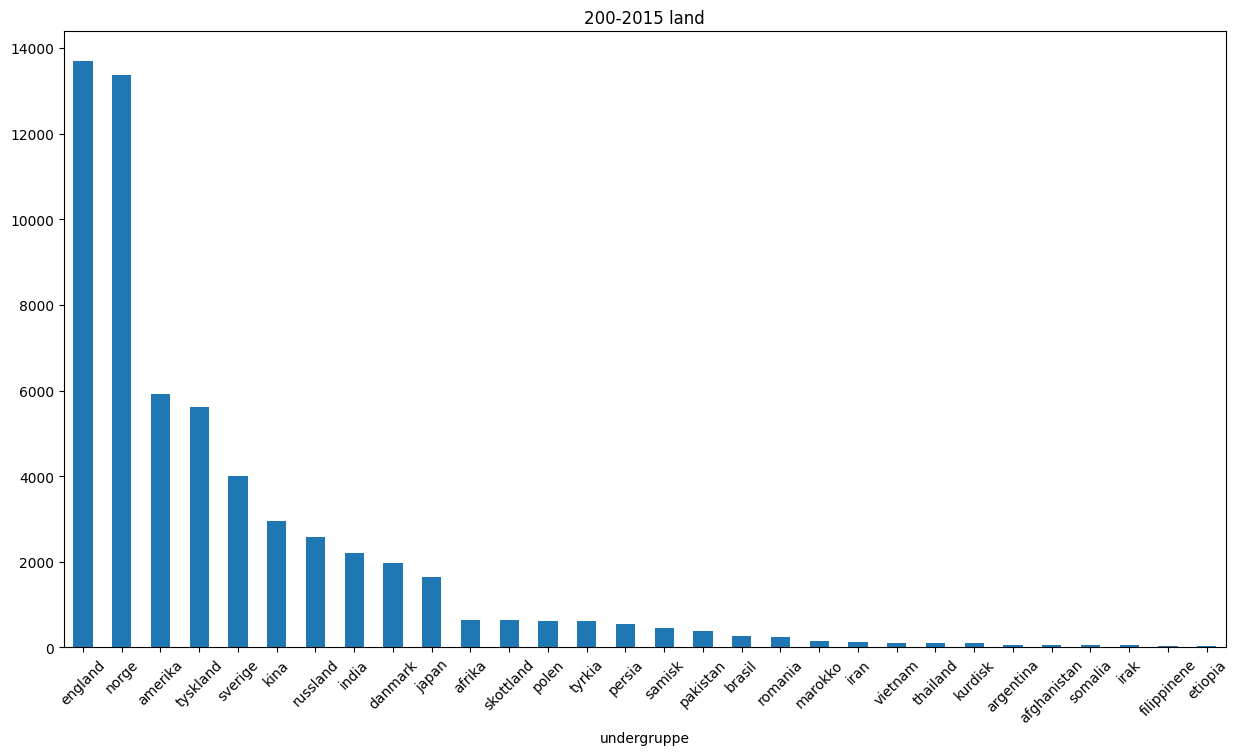

In [133]:
h2015_land.sum(axis=1).sort_values(ascending=False).head(30).plot(kind="bar", rot=45, figsize=(15, 8), title="200-2015 land")

<Axes: title={'center': '2016-2024 land'}, xlabel='undergruppe'>

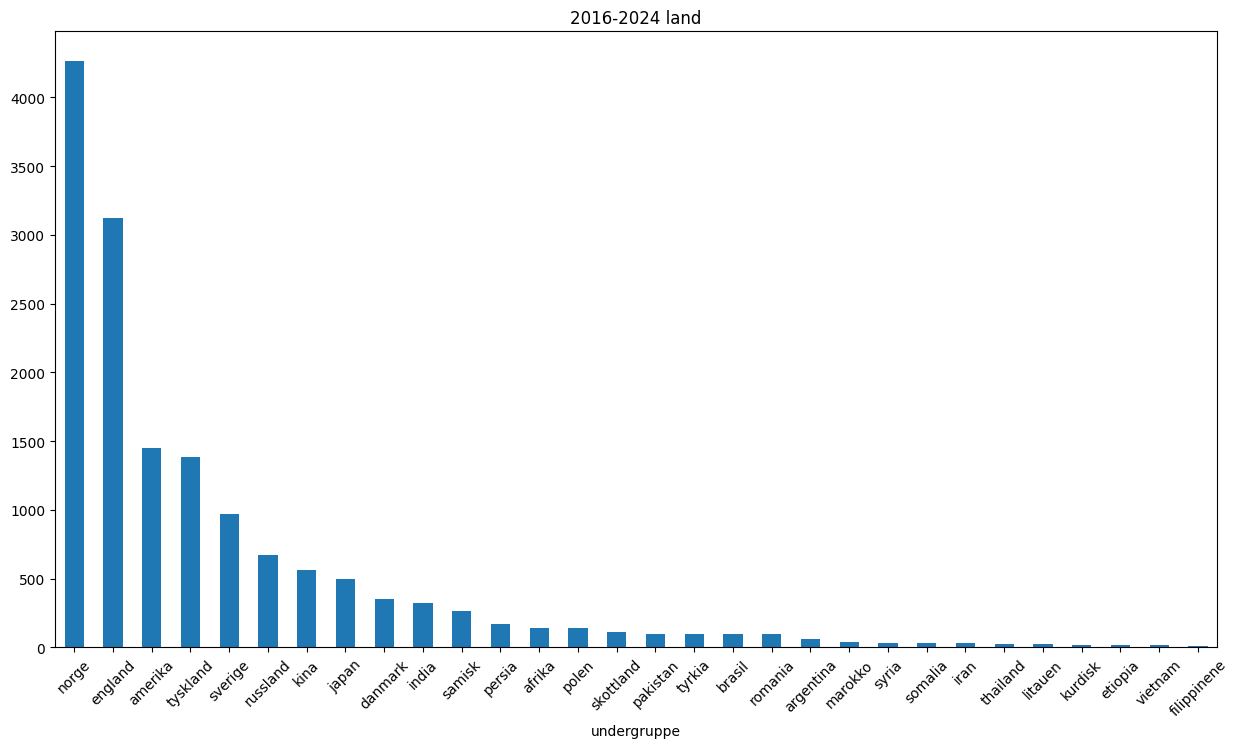

In [134]:
h2016_land.sum(axis=1).sort_values(ascending=False).head(30).plot(kind="bar", rot=45, figsize=(15, 8), title="2016-2024 land")

In [135]:
import numpy as np
import pandas as pd

freq = (counts > 0).sum(axis=1)     # bøker hvor markøren finnes
total = counts.sum(axis=1)          # totale forekomster
intensity = total / freq.replace(0, np.nan)

df = pd.DataFrame({
    "freq": freq,
    "intensity": intensity,
    "total": total
})

In [137]:
df[df.freq > 90].sort_values(by="intensity", ascending=False).head(10)

,freq,intensity,total
word,,,
Norge,5921,5.058943,29954.0
tyske,1919,4.304846,8261.0
England,5154,4.191696,21604.0
Pakistan,296,4.125000,1221.0
samisk,208,4.110577,855.0
Afghanistan,243,3.818930,928.0
engelsk,7291,3.629132,26460.0
India,1925,3.597922,6926.0
norske,4645,3.455544,16051.0


<Axes: xlabel='urn'>

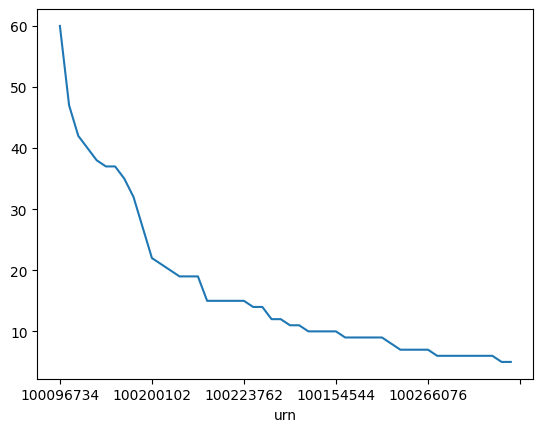

In [145]:
counts.loc["Pakistan"].sort_values(ascending=False).head(50).plot()


<Axes: xlabel='urn'>

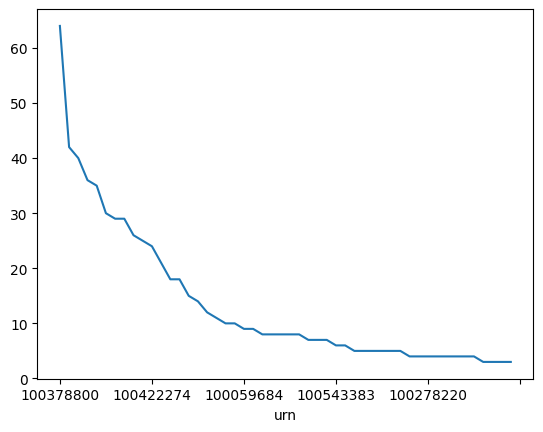

In [144]:
counts.loc["Afghanistan"].sort_values(ascending=False).head(50).plot()


<Axes: xlabel='urn'>

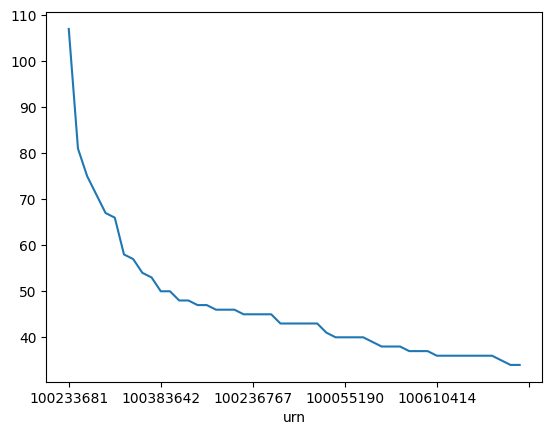

In [148]:
counts.loc["England"].sort_values(ascending=False).head(50).plot()


In [222]:
numcols = counts.columns

counts_lex = (
    counts.merge(lex_df, left_index=True, right_on="word")
    .groupby(["marker_type", "identity"])[numcols]
    .sum()
)

<Axes: xlabel='identity'>

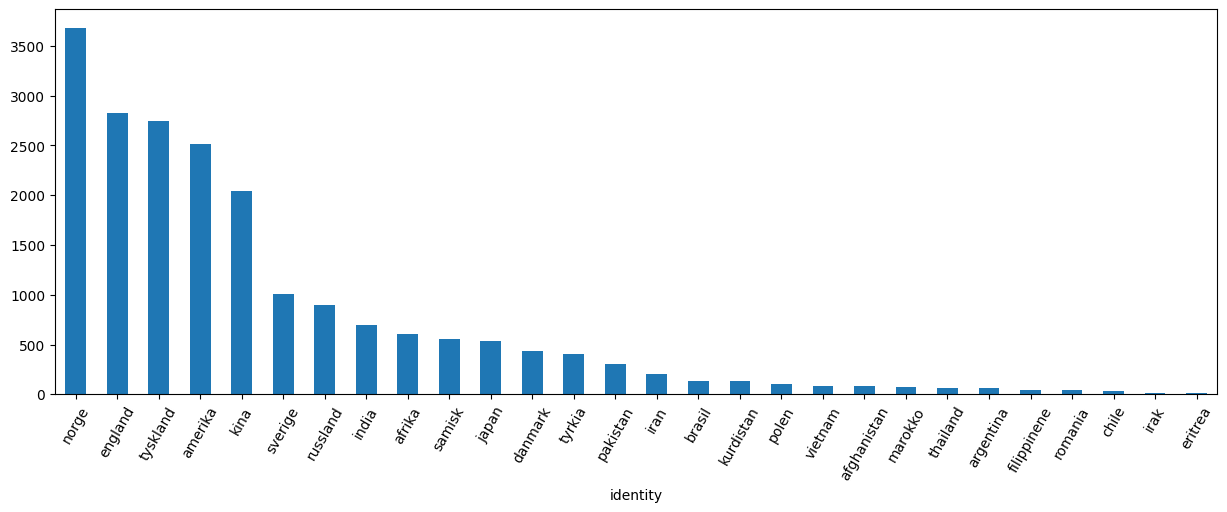

In [225]:
counts_lex.loc["demonym"].sum(axis=1).sort_values(ascending=False).plot(kind="bar", figsize=(15,5), rot=60)

In [226]:
import numpy as np
import pandas as pd
def intensity(counts):
    freq = (counts > 0).sum(axis=1)     # bøker hvor markøren finnes
    total = counts.sum(axis=1)          # totale forekomster
    intensity = total / freq.replace(0, np.nan)
    
    df = pd.DataFrame({
        "freq": freq,
        "intensity": intensity,
        "total": total
    })
    return df

In [228]:
demonym_intense = intensity(counts_lex.loc["demonym"])

In [234]:
topo_intense = intensity(counts_lex.loc["toponym"])

In [240]:
adj_intense = intensity(counts_lex.loc["adjective"])

<Axes: xlabel='identity'>

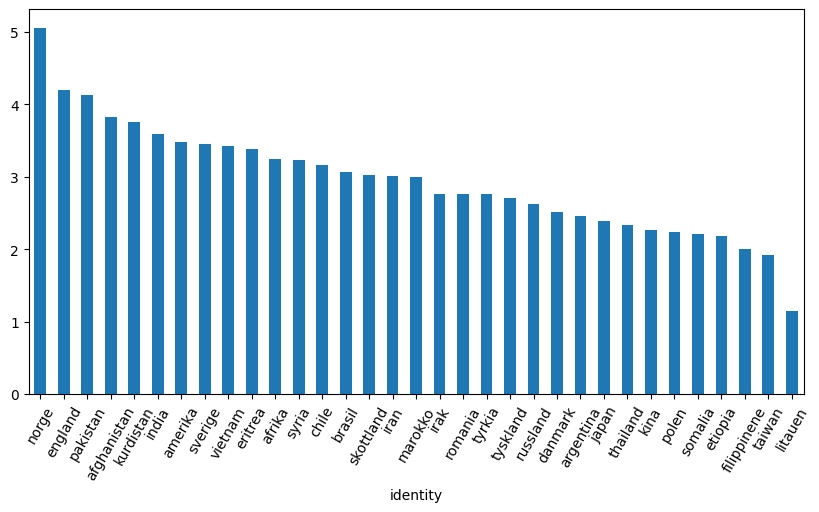

In [236]:
topo_intense["intensity"].sort_values(ascending=False).plot(kind="bar", figsize=(10,5), rot=60)

<Axes: xlabel='identity'>

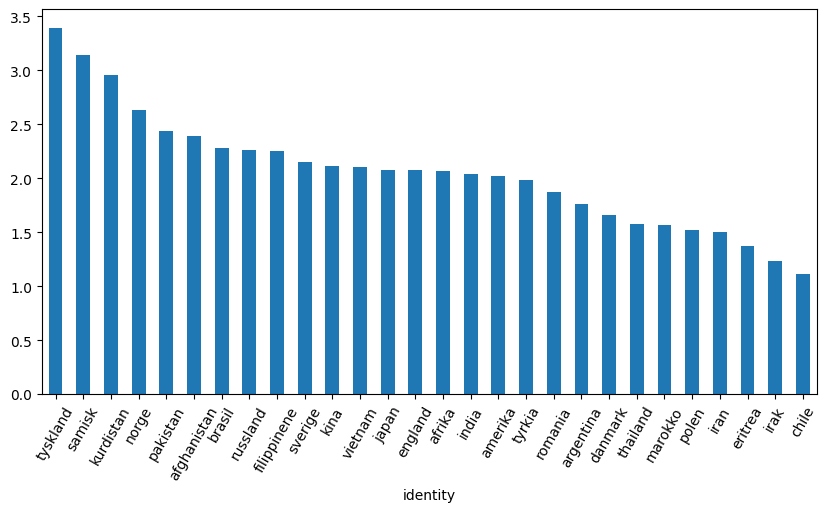

In [246]:
demonym_intense["intensity"].sort_values(ascending=False).plot(kind="bar", figsize=(10,5), rot=60)

<Axes: xlabel='identity'>

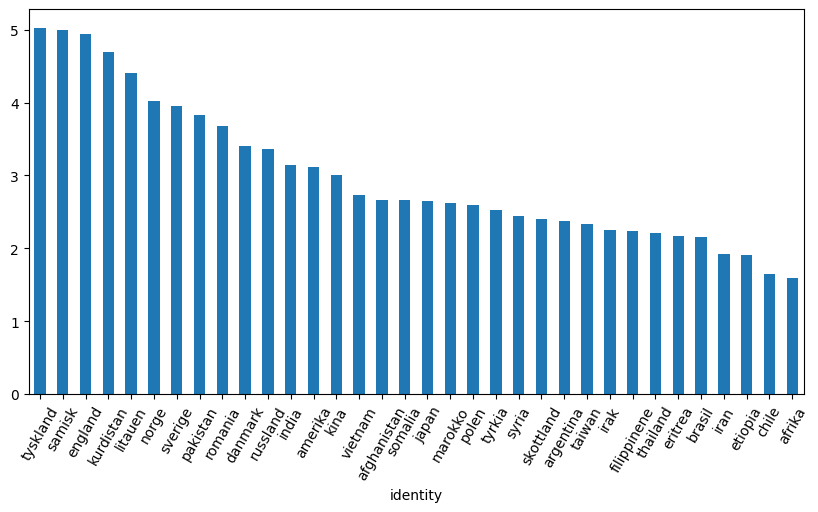

In [241]:
adj_intense["intensity"].sort_values(ascending=False).plot(kind="bar", figsize=(10,5), rot=60)

In [243]:
topo_intense.sort_values(by="intensity", ascending=False).head(5)

,freq,intensity,total
identity,,,
norge,5927,5.057871,29978.0
england,5155,4.193404,21617.0
pakistan,296,4.125000,1221.0
afghanistan,243,3.818930,928.0
kurdistan,28,3.750000,105.0


In [244]:
demonym_intense.sort_values(by="intensity", ascending=False).head(5)

,freq,intensity,total
identity,,,
tyskland,809,3.395550,2747.0
samisk,176,3.142045,553.0
kurdistan,44,2.954545,130.0
norge,1400,2.631429,3684.0
pakistan,123,2.439024,300.0


In [245]:
adj_intense.sort_values(by="intensity", ascending=False).head(5)

,freq,intensity,total
identity,,,
tyskland,3425,5.027737,17220.0
samisk,238,4.991597,1188.0
england,8629,4.936725,42599.0
kurdistan,39,4.692308,183.0
litauen,10,4.400000,44.0
